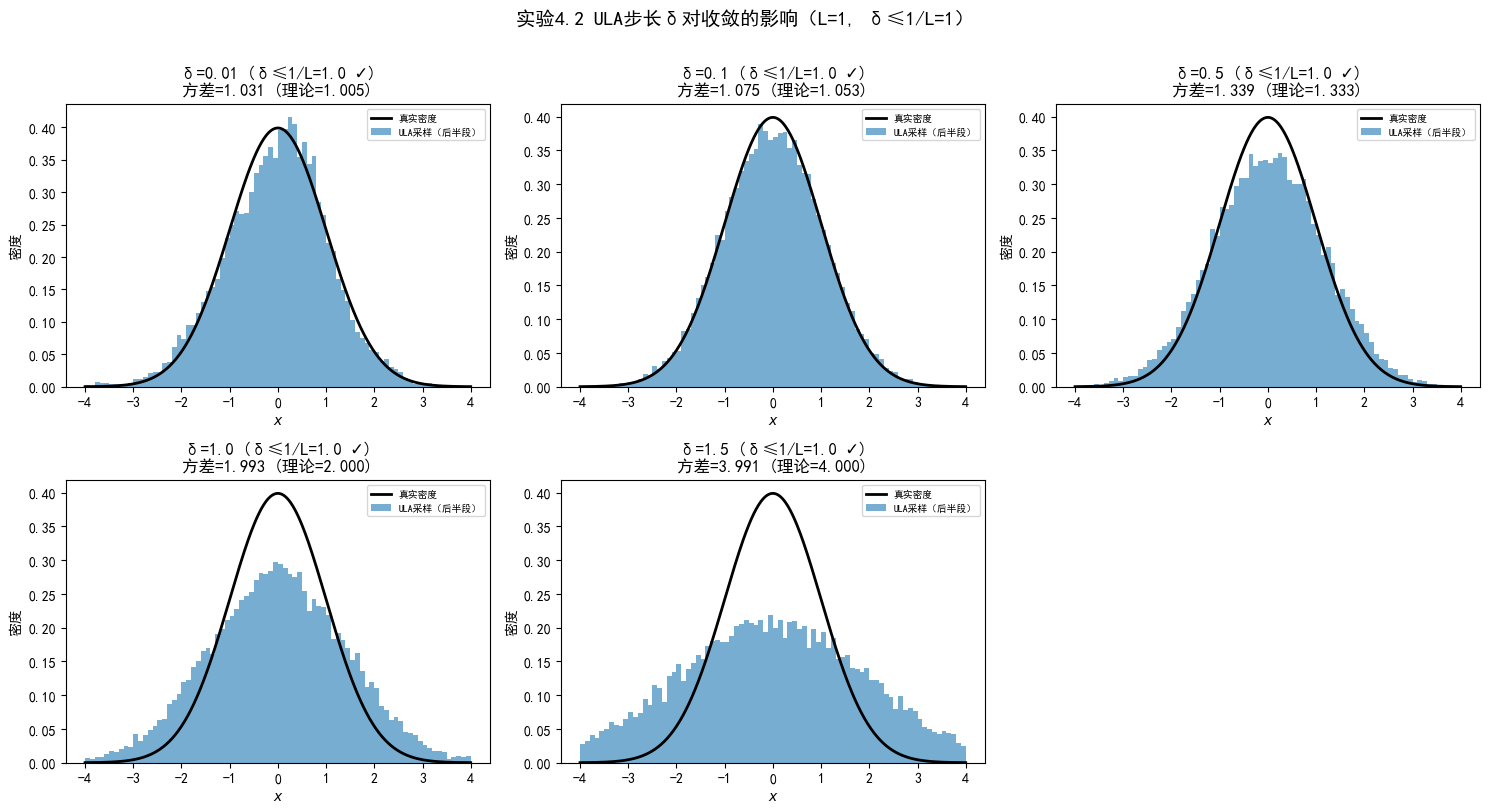

结论：
  δ ≤ 1/L 时ULA收敛，偏差随δ增大而增大
  δ > 1/L 时ULA发散，|X_m| → ∞
  权衡：小δ→偏差小但收敛慢；大δ→收敛快但偏差大


In [1]:
"""
实验4.2 ULA步长δ对收敛的影响
对应章节：4.3（步长条件δ≤1/L、偏差与收敛权衡、链发散）
素材来源：Mathematics.../Teaching Unit 2/labs/lab1_ULA_sol.ipynb
  - ULA_gauss() 函数
  - var_compare() 实验（原实验仅比较δ=0.1和δ=1.0两种步长）
  本实验扩展步长范围以展示发散行为
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# ULA_gauss 函数（取自 lab1_ULA_sol.ipynb，见实验4.1）
# ============================================================
def ULA_gauss(niter, delta, x0=0):
    Y = np.zeros(niter,)
    X = x0
    for i in range(niter):
        Z = np.random.randn()
        grad = X
        X_new = X - delta*grad + np.sqrt(2*delta)*Z
        # 检测发散
        if abs(X_new) > 1e6:
            Y[i:] = np.nan
            break
        X = X_new
        Y[i] = X
    return Y, np.var(Y[~np.isnan(Y)]) if not np.all(np.isnan(Y)) else float('inf')


# ============================================================
# 实验：不同步长下的ULA行为
# N(0,1) 的 L=1，步长条件 δ ≤ 1/L = 1
# ============================================================
n_iter = 50000
L = 1.0
delta_list = [0.01, 0.1, 0.5, 1.0, 1.5]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

x_grid = np.linspace(-4, 4, 500)
true_pdf = np.exp(-x_grid**2 / 2) / np.sqrt(2 * np.pi)

for idx, delta in enumerate(delta_list):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    
    chain, var_emp = ULA_gauss(n_iter, delta)
    valid = chain[~np.isnan(chain)]
    diverged = np.any(np.isnan(chain))
    
    if not diverged and len(valid) > 1000:
        ax.plot(x_grid, true_pdf, 'k-', linewidth=2, label='真实密度')
        ax.hist(valid[len(valid)//2:], bins=80, range=(-4, 4), 
                density=True, alpha=0.6, label='ULA采样（后半段）')
        var_theory = 2.0 / (2.0 - delta) if delta < 2 else float('inf')
        ax.set_title(f'δ={delta} (δ≤1/L={1/L} ✓)\n方差={var_emp:.3f} (理论={var_theory:.3f})')
    else:
        ax.text(0.5, 0.5, f'δ={delta} > 1/L={1/L}\n链发散！', 
                transform=ax.transAxes, ha='center', va='center',
                fontsize=14, color='red', fontweight='bold')
        ax.set_title(f'δ={delta} (δ>1/L={1/L}): 发散')
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('密度')
    ax.legend(fontsize=7)

# 隐藏多余子图
axes[1][2].axis('off')

fig.suptitle('实验4.2 ULA步长δ对收敛的影响（L=1, δ≤1/L=1）', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('实验4_2_ULA步长影响.png', dpi=150, bbox_inches='tight')
plt.show()

print("结论：")
print("  δ ≤ 1/L 时ULA收敛，偏差随δ增大而增大")
print("  δ > 1/L 时ULA发散，|X_m| → ∞")
print("  权衡：小δ→偏差小但收敛慢；大δ→收敛快但偏差大")
